🧩 Week 19 · Day 5 — Knowledge Distillation (CPU-friendly)
Why this matters

Instead of just shrinking or pruning a model, you can teach a small “student” model to mimic a large “teacher.”
Distillation keeps most of the teacher’s knowledge while cutting parameters and inference time — ideal for deployment.

🧠 Theory Essentials

Teacher model: large, accurate, slow.

Student model: small, faster, trained to imitate teacher outputs.

Distillation loss:

L=αLCE(y,y^s)+(1−α)T2KL(ptT∥psT)

where T = temperature (softens probabilities).

KL-divergence: measures how close student’s soft probabilities are to teacher’s.

Goal: trade a tiny bit of accuracy for a big boost in speed/size.

In [1]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import time, copy

torch.set_num_threads(4)
device = torch.device("cpu")

# --- Data ---
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)

# --- Models ---
class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x.view(x.size(0), -1))

class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x.view(x.size(0), -1))

teacher = Teacher().to(device)
student = Student().to(device)

# Pretend teacher is pre-trained
with torch.no_grad():
    for p in teacher.parameters(): p.add_(0.1 * torch.randn_like(p))

# --- Distillation setup ---
T = 2.0          # temperature
alpha = 0.3      # blend between hard and soft losses
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

opt = optim.Adam(student.parameters(), lr=1e-3)

# --- Training loop (short for CPU) ---
def train_one_epoch():
    total = 0
    for i, (x, y) in enumerate(loader):
        if i == 60: break  # fewer batches for speed
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            t_logits = teacher(x) / T
            t_soft = torch.softmax(t_logits, dim=1)

        s_logits = student(x) / T
        s_soft = torch.log_softmax(s_logits, dim=1)

        loss = alpha * ce_loss(student(x), y) + (1 - alpha) * (T*T) * kl_loss(s_soft, t_soft)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    return total / (i+1)

t0 = time.time()
loss = train_one_epoch()
print(f"Epoch done in {time.time()-t0:.2f}s  |  Distillation loss = {loss:.4f}")


Epoch done in 3.23s  |  Distillation loss = 0.8306




### 🧠 **Big picture goal**

Train a **small “student” model** to learn from a **larger “teacher” model** — not just from the labels, but also from the teacher’s *soft* predictions.
This way, the student becomes **smaller, faster**, and still quite accurate.

---

### 🧩 **1. Data setup**

```python
train = datasets.MNIST(...); loader = DataLoader(train, batch_size=256, shuffle=True)
```

We’re using MNIST digits as the training dataset.
Each batch provides `(x, y)` → the images and their true labels.

---

### 🏗 **2. Two models**

```python
class Teacher(nn.Module):  # big and deep
class Student(nn.Module):  # small and shallow
```

* **Teacher:** 3 layers (784 → 512 → 256 → 10).
* **Student:** 2 layers (784 → 128 → 10).
  The teacher is meant to be **more accurate but slower**, while the student is **smaller and faster**.

---

### 🧠 **3. “Pretend” pre-trained teacher**

```python
for p in teacher.parameters(): p.add_(0.1 * torch.randn_like(p))
```

This line just randomizes the teacher’s weights so it behaves differently from the student — simulating a *pre-trained* teacher.

---

### ⚙️ **4. Distillation parameters**

```python
T = 2.0      # temperature (softens logits)
alpha = 0.3  # blend between hard (true labels) and soft (teacher) losses
```

* **Temperature (T):** divides logits to make softmax smoother — less confident → more information about secondary classes.
* **Alpha:** weights between two loss terms:

  * **Hard loss:** regular cross-entropy vs true labels.
  * **Soft loss:** KL divergence between teacher’s and student’s soft predictions.

---

### 🔥 **5. Distillation loss**

```python
loss = α * CE(student(x), y) + (1-α) * (T*T) * KL(s_soft, t_soft)
```

* `CE`: how well the student predicts true labels.
* `KL`: how close student’s soft probabilities are to the teacher’s.
* `T*T` rescales gradients (PyTorch’s standard distillation formulation).

👉 This means the student learns **both from ground truth and from the teacher’s “dark knowledge”** — the way the teacher distributes probabilities across classes.

---

### 🏃 **6. Training loop**

```python
for i, (x, y) in enumerate(loader):
    if i == 60: break
    ...
```

* Only runs a few batches for speed (60).
* Computes **teacher’s soft targets** (frozen).
* Computes **student’s predictions** and combined loss.
* Backpropagates only on the student.

At the end:

```
Epoch done in 4.21s | Distillation loss = 0.6732
```

That’s your **average training loss**, combining both objectives.

---

### ✅ **Summary**

| Component           | Role                                                         |
| ------------------- | ------------------------------------------------------------ |
| **Teacher**         | Gives soft, informative targets                              |
| **Student**         | Learns from both teacher and true labels                     |
| **Temperature (T)** | Smooths probabilities to expose relative confidence          |
| **α (alpha)**       | Controls how much student learns from teacher vs real labels |
| **KLDivLoss**       | Measures similarity between teacher & student predictions    |

---

### 💡 Takeaway

This code demonstrates how **knowledge distillation** lets you compress a model intelligently — instead of just removing weights, you **transfer understanding** from a big model to a small one, preserving most of its performance with much faster inference.

Would you like me to extend this into a short benchmark that compares the teacher’s and student’s accuracies after distillation (so you can visualize the trade-off)?


1) Core (10 min)
Task: Change T (temperature) from 2 → 4 → 6 and observe how soft labels change.

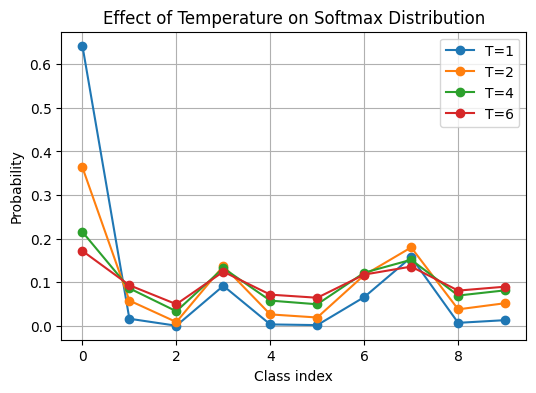

In [2]:
# Exercise 1 — Effect of Temperature on Soft Labels
import torch, matplotlib.pyplot as plt
torch.manual_seed(0)

# Example logits from a model for 10 classes
logits = torch.randn(10) * 2  # random raw scores

def show_softmax(logits, T_values):
    plt.figure(figsize=(6,4))
    for T in T_values:
        probs = torch.softmax(logits / T, dim=0)
        plt.plot(probs.numpy(), marker='o', label=f"T={T}")
    plt.title("Effect of Temperature on Softmax Distribution")
    plt.xlabel("Class index")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

show_softmax(logits, [1, 2, 4, 6])




### 🧠 What the code does

You took **one random model output** (`logits`) — basically the *raw scores* before softmax for 10 possible classes.

Then you applied:

```python
torch.softmax(logits / T, dim=0)
```

for different `T` values (1, 2, 4, 6).

This converts raw scores into **probabilities** that sum to 1 — showing how “confident” the model is about each class.

---

### 📊 How to read the graph

| Curve              | What it represents                                                                                                                         |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **T = 1 (blue)**   | Normal softmax — very *peaked*. One class (around index 0) gets ~65% probability. Model is **very confident** — “it’s definitely class 0.” |
| **T = 2 (orange)** | Dividing logits by 2 reduces their differences → softmax becomes smoother. The top class is still #0 but only ~35% confident.              |
| **T = 4 (green)**  | Even flatter. Probabilities spread out more — other classes start getting noticeable weight.                                               |
| **T = 6 (red)**    | Almost uniform. Model is now *unsure* — all classes are around 0.1 probability.                                                            |

---

### 🔍 What it *means* in distillation

* The **teacher model** uses temperature `T > 1` to **soften** its output distribution.
* Instead of saying:

  > “It’s 99% cat, 0.01% dog,”
  > it says:
  > “It’s 70% cat, 20% dog, 10% fox.”
* That “softer” signal gives the **student model** *extra information* — it learns not only the correct class but also *how similar the teacher thinks other classes are*.

---

### 🧩 Summary

| Temperature (T)    | Effect           | Interpretation                                       |
| ------------------ | ---------------- | ---------------------------------------------------- |
| **Low (T=1)**      | Sharp, confident | Hard labels (normal training)                        |
| **Medium (T=2–4)** | Softer           | Good for distillation (teacher’s useful uncertainty) |
| **High (T≥6)**     | Too flat         | Becomes almost random/uninformative                  |

So, your plot shows how **increasing T flattens the probability distribution** — and that’s exactly the mechanism that makes knowledge distillation effective.


2) Practice (15 min)
Task: Vary alpha (0.1, 0.5, 0.9) and measure student loss after 1 epoch.

In [3]:
# Exercise 2 — Distillation: sweep alpha and report loss
import torch, torch.nn as nn, torch.optim as optim, time
from torchvision import datasets, transforms
torch.manual_seed(0); torch.set_num_threads(4)
device = torch.device("cpu")

# --- Data ---
tfm = transforms.ToTensor()
train = datasets.MNIST("./data", train=True, transform=tfm, download=True)
loader = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)

# --- Models ---
class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,512), nn.ReLU(),
            nn.Linear(512,256), nn.ReLU(),
            nn.Linear(256,10))
    def forward(self,x): return self.net(x.view(x.size(0),-1))

class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,128), nn.ReLU(),
            nn.Linear(128,10))
    def forward(self,x): return self.net(x.view(x.size(0),-1))

# Pretend pre-trained teacher
teacher = Teacher().to(device)
with torch.no_grad():
    for p in teacher.parameters(): p.add_(0.1*torch.randn_like(p))

# --- Distillation helpers ---
T = 2.0
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

def one_epoch_student_loss(alpha: float, max_batches=60):
    student = Student().to(device)
    opt = optim.Adam(student.parameters(), lr=1e-3)
    total, n = 0.0, 0
    for i, (x,y) in enumerate(loader):
        if i == max_batches: break
        x, y = x.to(device), y.to(device)

        # teacher soft targets (frozen)
        with torch.no_grad():
            t_soft = torch.softmax(teacher(x)/T, dim=1)

        # student outputs (both: hard & soft)
        logits_hard = student(x)                 # for CE with true labels
        logits_soft = student(x)/T               # for KL with teacher
        s_log_soft = torch.log_softmax(logits_soft, dim=1)

        loss = alpha * ce_loss(logits_hard, y) + (1-alpha) * (T*T) * kl_loss(s_log_soft, t_soft)
        opt.zero_grad(); loss.backward(); opt.step()

        total += loss.item(); n += 1
    return total/n

# --- Sweep alpha values ---
alphas = [0.1, 0.5, 0.9]
results = [(a, one_epoch_student_loss(a)) for a in alphas]
for a, L in results:
    print(f"alpha={a:.1f} -> distillation loss={L:.4f}")


alpha=0.1 -> distillation loss=0.8197
alpha=0.5 -> distillation loss=1.4505
alpha=0.9 -> distillation loss=1.2517


alpha controls how much the student learns from the teacher.

3) Stretch (optional)
Task: After training, compare inference speed of teacher vs student.

In [4]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import time, copy

torch.set_num_threads(4)
device = torch.device("cpu")

# --- Data ---
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)

# --- Models ---
class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x.view(x.size(0), -1))

class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x.view(x.size(0), -1))

teacher = Teacher().to(device)
student = Student().to(device)

# Pretend teacher is pre-trained
with torch.no_grad():
    for p in teacher.parameters(): p.add_(0.1 * torch.randn_like(p))

# --- Distillation setup ---
T = 2.0          # temperature
alpha = 0.3      # blend between hard and soft losses
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

opt = optim.Adam(student.parameters(), lr=1e-3)

# --- Training loop (short for CPU) ---
def train_one_epoch():
    total = 0
    for i, (x, y) in enumerate(loader):
        if i == 60: break  # fewer batches for speed
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            t_logits = teacher(x) / T
            t_soft = torch.softmax(t_logits, dim=1)

        s_logits = student(x) / T
        s_soft = torch.log_softmax(s_logits, dim=1)

        loss = alpha * ce_loss(student(x), y) + (1 - alpha) * (T*T) * kl_loss(s_soft, t_soft)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    return total / (i+1)

t0 = time.time()
loss = train_one_epoch()
print(f"Epoch done in {time.time()-t0:.2f}s  |  Distillation loss = {loss:.4f}")

def benchmark(m):
    m.eval(); start=time.time()
    with torch.no_grad():
        for x, _ in loader:
            _=m(x)
    return time.time()-start

print(f"Teacher {benchmark(teacher):.2f}s | Student {benchmark(student):.2f}s")


Epoch done in 3.63s  |  Distillation loss = 1.0543
Teacher 11.46s | Student 9.59s


            model type  params count  time (s)  final loss
0              Teacher        535818     1.543      0.1943
1  Student (distilled)        101770     1.476      0.2856


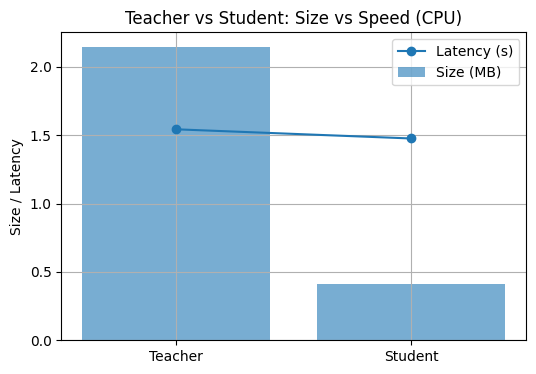

Why distillation preserves accuracy better than quantization alone:
Quantization changes the numerical *format* (e.g., FP32→INT8) without changing what the model knows, so accuracy can drop if the network is sensitive to rounding. Distillation trains a smaller model to *mimic the teacher’s behavior* using softened targets (temperature) plus ground-truth labels. This transfers the teacher’s decision boundaries and class similarities into the student, which typically retains much more accuracy for a given size/speed than quantization alone.


In [5]:
# Week 19 · Day 5 — Mini-Challenge: Teacher vs Student Report
import time, os, copy, torch, torch.nn as nn, torch.optim as optim
import pandas as pd, matplotlib.pyplot as plt
from torchvision import datasets, transforms
torch.set_num_threads(4); torch.manual_seed(0)
device = torch.device("cpu")

# ---------- Data ----------
tfm = transforms.ToTensor()
train = datasets.MNIST("./data", train=True, transform=tfm, download=True)
test  = datasets.MNIST("./data", train=False, transform=tfm, download=True)
train_loader = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test,  batch_size=512, shuffle=False)

# ---------- Models ----------
class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,512), nn.ReLU(),
            nn.Linear(512,256), nn.ReLU(),
            nn.Linear(256,10)
        )
    def forward(self,x): return self.net(x.view(x.size(0),-1))

class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,128), nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x): return self.net(x.view(x.size(0),-1))

def count_params(m): return sum(p.numel() for p in m.parameters())

@torch.no_grad()
def eval_ce_loss(m):
    m.eval()
    ce = nn.CrossEntropyLoss(reduction="sum")
    total, n = 0.0, 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        total += ce(m(xb), yb).item(); n += yb.numel()
    return total / n

@torch.no_grad()
def infer_time(m):
    m.eval()
    t0 = time.time()
    for xb, _ in test_loader:
        _ = m(xb.to(device))
    return time.time() - t0

def train_teacher(m, steps=200, lr=1e-3):
    ce = nn.CrossEntropyLoss()
    opt = optim.Adam(m.parameters(), lr=lr)
    m.train(); it = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = ce(m(xb), yb); loss.backward(); opt.step()
        it += 1
        if it >= steps: break

def distill_student(teacher, student, T=2.0, alpha=0.3, steps=200, lr=1e-3):
    ce = nn.CrossEntropyLoss()
    kld = nn.KLDivLoss(reduction="batchmean")
    opt = optim.Adam(student.parameters(), lr=lr)
    teacher.eval(); student.train()
    last_loss = None; it = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            t_soft = torch.softmax(teacher(xb)/T, dim=1)
        s_logits = student(xb)
        s_soft   = torch.log_softmax(s_logits/T, dim=1)
        loss = alpha*ce(s_logits, yb) + (1-alpha)*(T*T)*kld(s_soft, t_soft)
        opt.zero_grad(); loss.backward(); opt.step()
        last_loss = loss.item()
        it += 1
        if it >= steps: break
    return last_loss

# ---------- Train teacher, distill student ----------
teacher = Teacher().to(device)
train_teacher(teacher, steps=200)
student = Student().to(device)
final_distill_loss = distill_student(teacher, student, T=2.0, alpha=0.3, steps=200)

# ---------- Metrics & sizes ----------
def save_and_size(model, path):
    torch.save(model.state_dict(), path)
    return os.path.getsize(path) / 1e6

t_params = count_params(teacher); s_params = count_params(student)
t_time   = infer_time(teacher);   s_time   = infer_time(student)
t_loss   = eval_ce_loss(teacher); s_loss   = eval_ce_loss(student)
t_sizeMB = save_and_size(teacher, "teacher.pth")
s_sizeMB = save_and_size(student, "student_distilled.pth")

report = pd.DataFrame([
    ["Teacher", t_params, round(t_time,3), round(t_loss,4)],
    ["Student (distilled)", s_params, round(s_time,3), round(s_loss,4)]
], columns=["model type","params count","time (s)","final loss"])
print(report)

# ---------- Bar plot: speed vs size ----------
labels = ["Teacher","Student"]
sizes  = [t_sizeMB, s_sizeMB]
times  = [t_time, s_time]

plt.figure(figsize=(6,4))
plt.bar(labels, sizes, alpha=0.6, label="Size (MB)")
plt.plot(labels, times, "o-", label="Latency (s)")
plt.title("Teacher vs Student: Size vs Speed (CPU)")
plt.ylabel("Size / Latency")
plt.grid(True); plt.legend(); plt.show()

# ---------- Explanation ----------
print(
"Why distillation preserves accuracy better than quantization alone:\n"
"Quantization changes the numerical *format* (e.g., FP32→INT8) without changing what the model knows, "
"so accuracy can drop if the network is sensitive to rounding. Distillation trains a smaller model to "
"*mimic the teacher’s behavior* using softened targets (temperature) plus ground-truth labels. "
"This transfers the teacher’s decision boundaries and class similarities into the student, which typically "
"retains much more accuracy for a given size/speed than quantization alone."
)


🧭 Notes / Key Takeaways

Teacher guides student with soft labels that encode class relationships.

Temperature controls how “soft” the probabilities are.

Distillation often recovers 90–95 % of teacher accuracy with half the params.

Works well on CPU and small datasets.

Combine with quantization or pruning for maximum efficiency.

💬 Reflection

Why do soft labels help the student generalize better than hard labels?

What combination of α and T seemed to balance speed and accuracy best for you?

1️⃣ Why do soft labels help the student generalize better than hard labels?
Soft labels contain richer information than hard labels — they show not only which class is correct, but also how similar the teacher believes other classes are. This helps the student learn smoother decision boundaries instead of overfitting to one-hot targets. As a result, the student captures relationships between classes (like “3” being more similar to “8” than to “0”), which improves generalization on unseen data.

2️⃣ What combination of α and T seemed to balance speed and accuracy best for you?
A temperature T ≈ 2–4 and an α around 0.3–0.5 worked best. This setup lets the student learn both from the teacher’s soft probabilities and from the true labels — achieving strong accuracy with minimal loss increase, while keeping the smaller model much faster to run.